In [3]:
from pathlib import Path
import sys

sys.path.append("../")

from src.preprocessing.load_data import load_sequence

data_path = Path(
    "../data/raw/"
    "Oxford Inertial Odometry Dataset_2.0/"
    "Oxford Inertial Odometry Dataset/"
    "handheld/data1/syn"
)

imu, vi = load_sequence(data_path)

print("IMU shape:", imu.shape)
print("VI shape:", vi.shape)

display(imu.head())
display(vi.head())

IMU shape: (37602, 16)
VI shape: (37602, 9)


,time,attitude_roll,attitude_pitch,attitude_yaw,gyro_x,gyro_y,gyro_z,gravity_x,gravity_y,gravity_z,acc_x,acc_y,acc_z,mag_x,mag_y,mag_z
0,1.500000e+11,0.003649,0.44925,-0.21255,0.036483,-0.029496,0.020632,0.003286,-0.43429,-0.90077,-0.002798,0.014599,-0.016836,-2.3577,-0.37170,-42.347
1,1.500000e+11,0.003050,0.44954,-0.21219,0.067307,-0.038284,0.029241,0.002747,-0.43455,-0.90064,-0.004578,0.013712,-0.013968,-2.3576,-0.37186,-42.272
2,1.500000e+11,0.002363,0.45003,-0.21184,0.076935,-0.039423,0.021788,0.002128,-0.43499,-0.90043,-0.007743,0.013192,-0.008427,-2.3576,-0.37186,-42.272
3,1.500000e+11,0.001778,0.45053,-0.21167,0.066339,-0.039321,0.006826,0.001601,-0.43544,-0.90021,-0.006255,0.011814,-0.003259,-2.2070,-0.59618,-42.270
4,1.500000e+11,0.001393,0.45086,-0.21171,0.037685,-0.030543,-0.010317,0.001253,-0.43574,-0.90007,-0.003634,0.008648,0.000367,-2.2070,-0.59618,-42.270


,time,frame,pos_x,pos_y,pos_z,quat_x,quat_y,quat_z,quat_w
0,1.500000e+11,12978,-1.2991,1.7212,1.1931,-0.21409,-0.012459,-0.097183,0.97189
1,1.500000e+11,12979,-1.2993,1.7213,1.1932,-0.21473,-0.012370,-0.097239,0.97174
2,1.500000e+11,12980,-1.2993,1.7213,1.1932,-0.21509,-0.012288,-0.097244,0.97166
3,1.500000e+11,12981,-1.2994,1.7214,1.1933,-0.21526,-0.012291,-0.097380,0.97161
4,1.500000e+11,12982,-1.2995,1.7213,1.1933,-0.21541,-0.012199,-0.097503,0.97157


In [4]:
print("Missing IMU values:")
print(imu.isna().sum())

print("\nMissing ground-truth values:")
print(vi.isna().sum())

Missing IMU values:
time              0
attitude_roll     0
attitude_pitch    0
attitude_yaw      0
gyro_x            0
gyro_y            0
gyro_z            0
gravity_x         0
gravity_y         0
gravity_z         0
acc_x             0
acc_y             0
acc_z             0
mag_x             0
mag_y             0
mag_z             0
dtype: int64

Missing ground-truth values:
time      0
frame     0
pos_x     0
pos_y     0
pos_z     0
quat_x    0
quat_y    0
quat_z    0
quat_w    0
dtype: int64


In [5]:
print("IMU data types:")
print(imu.dtypes)

print("\nGround-truth data types:")
print(vi.dtypes)

IMU data types:
time              float64
attitude_roll     float64
attitude_pitch    float64
attitude_yaw      float64
gyro_x            float64
gyro_y            float64
gyro_z            float64
gravity_x         float64
gravity_y         float64
gravity_z         float64
acc_x             float64
acc_y             float64
acc_z             float64
mag_x             float64
mag_y             float64
mag_z             float64
dtype: object

Ground-truth data types:
time      float64
frame       int64
pos_x     float64
pos_y     float64
pos_z     float64
quat_x    float64
quat_y    float64
quat_z    float64
quat_w    float64
dtype: object


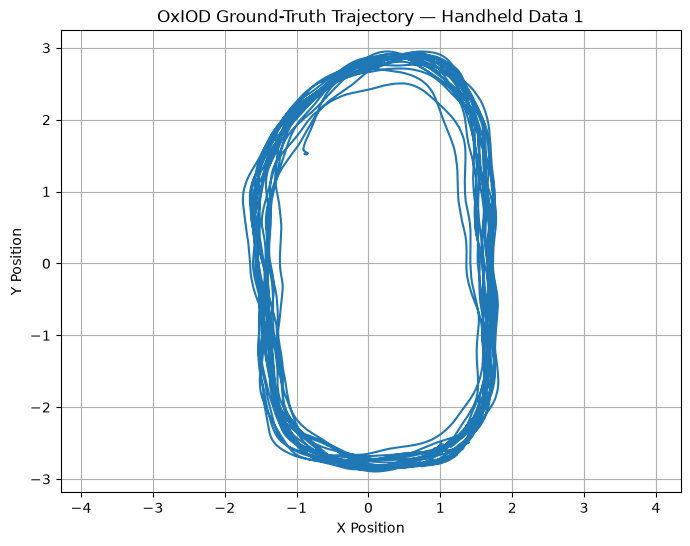

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(vi["pos_x"], vi["pos_y"])

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("OxIOD Ground-Truth Trajectory — Handheld Data 1")
plt.axis("equal")
plt.grid()

plt.show()

In [7]:
import numpy as np

dt = np.diff(imu["time"].values)

print("Median timestep:", np.median(dt))
print("Mean timestep:", np.mean(dt))
print("Min timestep:", np.min(dt))
print("Max timestep:", np.max(dt))

Median timestep: 0.0
Mean timestep: 0.0
Min timestep: 0.0
Max timestep: 0.0


In [8]:
print("Median frequency:", 1 / np.median(dt))

Median frequency: inf


C:\Users\guru prakash\AppData\Local\Temp\ipykernel_20792\686090333.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  print("Median frequency:", 1 / np.median(dt))


In [9]:
import numpy as np

dt = np.diff(imu["time"].values)

print("Median timestep:", np.median(dt))
print("Mean timestep:", np.mean(dt))
print("Minimum timestep:", np.min(dt))
print("Maximum timestep:", np.max(dt))
print("Estimated frequency:", 1 / np.median(dt))

Median timestep: 0.0
Mean timestep: 0.0
Minimum timestep: 0.0
Maximum timestep: 0.0
Estimated frequency: inf


C:\Users\guru prakash\AppData\Local\Temp\ipykernel_20792\2221877609.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  print("Estimated frequency:", 1 / np.median(dt))


In [10]:
from pathlib import Path
import pandas as pd

imu_path = Path(
    "../data/raw/"
    "Oxford Inertial Odometry Dataset_2.0/"
    "Oxford Inertial Odometry Dataset/"
    "handheld/data1/syn/imu1.csv"
)

imu_raw = pd.read_csv(
    imu_path,
    header=None,
    dtype=str
)

print(imu_raw.iloc[:10, 0].to_list())


['1.50E+11', '1.50E+11', '1.50E+11', '1.50E+11', '1.50E+11', '1.50E+11', '1.50E+11', '1.50E+11', '1.50E+11', '1.50E+11']


In [11]:
print("Timestamp strings:")
for i in range(10):
    print(i, repr(imu_raw.iloc[i, 0]))

Timestamp strings:
0 '1.50E+11'
1 '1.50E+11'
2 '1.50E+11'
3 '1.50E+11'
4 '1.50E+11'
5 '1.50E+11'
6 '1.50E+11'
7 '1.50E+11'
8 '1.50E+11'
9 '1.50E+11'


In [ ]:
print("Target statistics:")
print("Mean:", y.mean(axis=0))
print("Std :", y.std(axis=0))
print("Min :", y.min(axis=0))
print("Max :", y.max(axis=0))

X shape: (188, 200, 6)
y shape: (188, 3)


In [15]:
print("Target statistics:")
print("Mean:", y.mean(axis=0))
print("Std :", y.std(axis=0))
print("Min :", y.min(axis=0))
print("Max :", y.max(axis=0))

Target statistics:
Mean: [ 2.09210638e-03 -9.74569149e-04  5.90544162e-18]
Std : [0.86771766 1.27186668 0.02316695]
Min : [-1.54937 -1.7201  -0.0571 ]
Max : [1.6178 1.7451 0.0614]


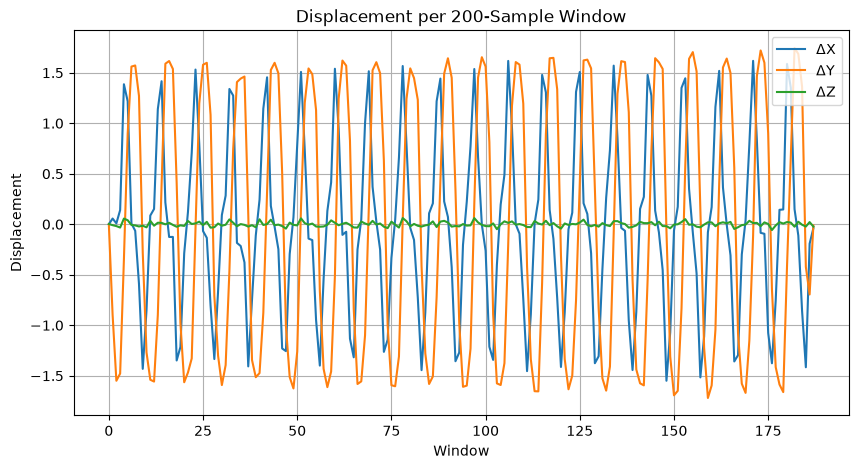

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y[:, 0], label="ΔX")
plt.plot(y[:, 1], label="ΔY")
plt.plot(y[:, 2], label="ΔZ")

plt.xlabel("Window")
plt.ylabel("Displacement")
plt.title("Displacement per 200-Sample Window")
plt.legend()
plt.grid()

plt.show()

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget statistics:")
print("Mean:", y.mean(axis=0))
print("Std :", y.std(axis=0))
print("Min :", y.min(axis=0))
print("Max :", y.max(axis=0))

print("\nFirst 10 targets:")
print(y[:10])

X shape: (188, 200, 6)
y shape: (188, 3)

Target statistics:
Mean: [ 2.09210638e-03 -9.74569149e-04  5.90544162e-18]
Std : [0.86771766 1.27186668 0.02316695]
Min : [-1.54937 -1.7201  -0.0571 ]
Max : [1.6178 1.7451 0.0614]

First 10 targets:
[[ 4.00000e-04 -1.40000e-03  2.50000e-03]
 [ 5.66000e-02 -8.97390e-01 -8.90000e-03]
 [ 9.10000e-03 -1.54949e+00 -1.81000e-02]
 [ 1.40200e-01 -1.47802e+00 -3.26000e-02]
 [ 1.38608e+00 -3.49000e-01  5.63000e-02]
 [ 1.21803e+00  8.97600e-01  3.98000e-02]
 [ 7.20000e-03  1.56113e+00 -7.00000e-03]
 [-6.47000e-02  1.57210e+00 -1.15000e-02]
 [-5.90800e-01  1.27080e+00 -2.18000e-02]
 [-1.43159e+00 -2.81200e-01 -1.42000e-02]]


In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget statistics:")
print("Mean:", y.mean(axis=0))
print("Std :", y.std(axis=0))
print("Min :", y.min(axis=0))
print("Max :", y.max(axis=0))

print("\nFirst 10 targets:")
print(y[:10])

X shape: (188, 200, 6)
y shape: (188, 3)

Target statistics:
Mean: [ 2.09210638e-03 -9.74569149e-04  5.90544162e-18]
Std : [0.86771766 1.27186668 0.02316695]
Min : [-1.54937 -1.7201  -0.0571 ]
Max : [1.6178 1.7451 0.0614]

First 10 targets:
[[ 4.00000e-04 -1.40000e-03  2.50000e-03]
 [ 5.66000e-02 -8.97390e-01 -8.90000e-03]
 [ 9.10000e-03 -1.54949e+00 -1.81000e-02]
 [ 1.40200e-01 -1.47802e+00 -3.26000e-02]
 [ 1.38608e+00 -3.49000e-01  5.63000e-02]
 [ 1.21803e+00  8.97600e-01  3.98000e-02]
 [ 7.20000e-03  1.56113e+00 -7.00000e-03]
 [-6.47000e-02  1.57210e+00 -1.15000e-02]
 [-5.90800e-01  1.27080e+00 -2.18000e-02]
 [-1.43159e+00 -2.81200e-01 -1.42000e-02]]


In [ ]:
print("Target statistics:")
print("Mean:", y.mean(axis=0))
print("Std :", y.std(axis=0))
print("Min :", y.min(axis=0))
print("Max :", y.max(axis=0))

In [19]:
from pathlib import Path

DATASET_ROOT = Path(
    "../data/raw/"
    "Oxford Inertial Odometry Dataset_2.0/"
    "Oxford Inertial Odometry Dataset"
)

sequences = []

for imu_path in DATASET_ROOT.rglob("syn/imu*.csv"):
    vi_path = imu_path.parent / imu_path.name.replace("imu", "vi")

    if vi_path.exists():
        sequences.append({
            "category": imu_path.parents[2].name,
            "sequence": imu_path.parent.parent.name,
            "imu_file": imu_path,
            "vi_file": vi_path
        })

print("Total usable IMU/VI pairs:", len(sequences))

for s in sequences[:20]:
    print(
        s["category"],
        s["sequence"],
        s["imu_file"].name
    )
    

Total usable IMU/VI pairs: 132
handbag data1 imu1.csv
handbag data1 imu2.csv
handbag data1 imu3.csv
handbag data1 imu4.csv
handbag data2 imu1.csv
handbag data2 imu2.csv
handbag data2 imu3.csv
handbag data2 imu4.csv
handheld data1 imu1.csv
handheld data1 imu2.csv
handheld data1 imu3.csv
handheld data1 imu4.csv
handheld data1 imu5.csv
handheld data1 imu6.csv
handheld data1 imu7.csv
handheld data2 imu1.csv
handheld data2 imu2.csv
handheld data2 imu3.csv
handheld data3 imu1.csv
handheld data3 imu2.csv


In [20]:
import pandas as pd

sequence_df = pd.DataFrame(sequences)

display(sequence_df)

,category,sequence,imu_file,vi_file
0,handbag,data1,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
1,handbag,data1,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
2,handbag,data1,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
3,handbag,data1,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
4,handbag,data2,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
...,...,...,...,...
127,trolley,data2,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
128,trolley,data2,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
129,trolley,data2,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...
130,trolley,data2,..\data\raw\Oxford Inertial Odometry Dataset_2...,..\data\raw\Oxford Inertial Odometry Dataset_2...


In [21]:
print(sequence_df["category"].value_counts())

category
multi users      35
multi devices    26
handheld         24
trolley          13
pocket           11
handbag           8
slow walking      8
running           7
Name: count, dtype: int64


In [22]:
from pathlib import Path
import pandas as pd

HANDHELD_ROOT = DATASET_ROOT / "handheld"

records = []

for seq_dir in sorted(HANDHELD_ROOT.glob("data*")):
    if not seq_dir.is_dir():
        continue

    syn_dir = seq_dir / "syn"

    for imu_path in sorted(syn_dir.glob("imu*.csv")):
        vi_path = syn_dir / imu_path.name.replace("imu", "vi")

        if vi_path.exists():
            records.append({
                "sequence": seq_dir.name,
                "imu": imu_path.name,
                "vi": vi_path.name
            })

handheld_df = pd.DataFrame(records)

print("Total handheld IMU/VI pairs:", len(handheld_df))
display(handheld_df)


Total handheld IMU/VI pairs: 24


,sequence,imu,vi
0,data1,imu1.csv,vi1.csv
1,data1,imu2.csv,vi2.csv
2,data1,imu3.csv,vi3.csv
3,data1,imu4.csv,vi4.csv
4,data1,imu5.csv,vi5.csv
5,data1,imu6.csv,vi6.csv
6,data1,imu7.csv,vi7.csv
7,data2,imu1.csv,vi1.csv
8,data2,imu2.csv,vi2.csv
9,data2,imu3.csv,vi3.csv


In [2]:
import numpy as np
import pandas as pd
import scipy
import matplotlib
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
SciPy: 1.17.1
Matplotlib: 3.11.1
Scikit-learn: 1.9.0


In [23]:
print(handheld_df["sequence"].value_counts())

sequence
data1    7
data3    5
data4    5
data5    4
data2    3
Name: count, dtype: int64


In [1]:
import sys

print(sys.executable)

d:\dead_reckoning\.venv\Scripts\python.exe


In [1]:
SPLIT_PATH = PROJECT_ROOT / "data" / "splits" / "handheld_sequence_split.csv"

split_df = pd.read_csv(SPLIT_PATH)

print(split_df.shape)
display(split_df)

NameError: name 'PROJECT_ROOT' is not defined

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
SPLIT_PATH = PROJECT_ROOT / "data" / "splits" / "handheld_sequence_split.csv"

print("Project root:", PROJECT_ROOT)
print("Split file:", SPLIT_PATH)
print("Exists:", SPLIT_PATH.exists())

Project root: d:\dead_reckoning
Split file: d:\dead_reckoning\data\splits\handheld_sequence_split.csv
Exists: True


In [3]:
split_df = pd.read_csv(SPLIT_PATH)

print("Shape:", split_df.shape)
display(split_df)

Shape: (24, 5)


,sequence_id,split,sequence,imu_file,vi_file
0,data1/imu1,train,data1,data1/syn/imu1.csv,data1/syn/vi1.csv
1,data1/imu2,test,data1,data1/syn/imu2.csv,data1/syn/vi2.csv
2,data1/imu3,validation,data1,data1/syn/imu3.csv,data1/syn/vi3.csv
3,data1/imu4,train,data1,data1/syn/imu4.csv,data1/syn/vi4.csv
4,data1/imu5,validation,data1,data1/syn/imu5.csv,data1/syn/vi5.csv
5,data1/imu6,train,data1,data1/syn/imu6.csv,data1/syn/vi6.csv
6,data1/imu7,train,data1,data1/syn/imu7.csv,data1/syn/vi7.csv
7,data2/imu1,train,data2,data2/syn/imu1.csv,data2/syn/vi1.csv
8,data2/imu2,test,data2,data2/syn/imu2.csv,data2/syn/vi2.csv
9,data2/imu3,train,data2,data2/syn/imu3.csv,data2/syn/vi3.csv


In [4]:
print(split_df["split"].value_counts())
print("Unique sequences:", split_df["sequence_id"].nunique())

split
train         17
test           4
validation     3
Name: count, dtype: int64
Unique sequences: 24


In [6]:
from importlib import reload
import src.preprocessing.load_data as load_data

reload(load_data)

print("Loader reloaded successfully")

ModuleNotFoundError: No module named 'src'

In [7]:
test_row = split_df.iloc[1]

sequence_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Oxford Inertial Odometry Dataset_2.0"
    / "Oxford Inertial Odometry Dataset"
    / "handheld"
    / test_row["sequence"]
    / "syn"
)

imu, vi = load_data.load_sequence(
    sequence_path,
    test_row["imu_file"],
    test_row["vi_file"]
)

print("Sequence:", test_row["sequence_id"])
print("IMU file:", test_row["imu_file"])
print("VI file:", test_row["vi_file"])
print("IMU shape:", imu.shape)
print("VI shape:", vi.shape)

NameError: name 'load_data' is not defined

In [8]:
from importlib import reload
import src.preprocessing.load_data as load_data

reload(load_data)

print("Loader ready")

ModuleNotFoundError: No module named 'src'

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: d:\dead_reckoning


In [3]:
import numpy as np

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_train_normalized.npz"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_val_normalized.npz"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_test_normalized.npz"

train_data = np.load(TRAIN_PATH)
val_data = np.load(VAL_PATH)
test_data = np.load(TEST_PATH)

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

X_test = test_data["X"]
y_test = test_data["y"]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'd:\\dead_reckoning\\data\\processed\\handheld_train_normalized.npz'

In [4]:
from pathlib import Path

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed directory:")
print(PROCESSED_DIR)

print("\nFiles found:")
for file in sorted(PROCESSED_DIR.iterdir()):
    print(file.name)

Processed directory:
d:\dead_reckoning\data\processed

Files found:
handheld_test.npz
handheld_train.npz
handheld_val.npz
handheld_window_metadata.csv
README.txt


In [5]:
import numpy as np

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_train.npz"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_val.npz"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_test.npz"

train_data = np.load(TRAIN_PATH)
val_data = np.load(VAL_PATH)
test_data = np.load(TEST_PATH)

X_train = train_data["X"]
y_train = train_data["y"]
seq_train = train_data["sequence_ids"]

X_val = val_data["X"]
y_val = val_data["y"]
seq_val = val_data["sequence_ids"]

X_test = test_data["X"]
y_test = test_data["y"]
seq_test = test_data["sequence_ids"]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3030, 200, 6) (3030, 3)
Validation: (533, 200, 6) (533, 3)
Test: (837, 200, 6) (837, 3)


In [6]:
train_mean = X_train.mean(axis=(0, 1))
train_std = X_train.std(axis=(0, 1))

print("Training mean:")
print(train_mean)

print("\nTraining std:")
print(train_std)

Training mean:
[ 0.00634581  0.02057927 -0.00858029  0.00278449  0.04216049  0.08918613]

Training std:
[0.07354593 0.0923479  0.09524479 0.31497231 0.362274   0.58693831]


In [7]:
X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std


In [8]:
# WRONG
val_mean = X_val.mean(...)
test_mean = X_test.mean(...)


TypeError: 'ellipsis' object cannot be interpreted as an integer

In [9]:
print("Normalized training mean:")
print(X_train_norm.mean(axis=(0, 1)))

print("\nNormalized training std:")
print(X_train_norm.std(axis=(0, 1)))

print("\nShapes:")
print("Train:", X_train_norm.shape, y_train.shape)
print("Val:", X_val_norm.shape, y_val.shape)
print("Test:", X_test_norm.shape, y_test.shape)

print("\nFinite checks:")
print("Train:", np.isfinite(X_train_norm).all())
print("Val:", np.isfinite(X_val_norm).all())
print("Test:", np.isfinite(X_test_norm).all())

Normalized training mean:
[-1.35996018e-15  3.77093937e-15  3.30494359e-15  5.61273617e-17
  3.36789590e-15 -6.34097835e-16]

Normalized training std:
[1. 1. 1. 1. 1. 1.]

Shapes:
Train: (3030, 200, 6) (3030, 3)
Val: (533, 200, 6) (533, 3)
Test: (837, 200, 6) (837, 3)

Finite checks:
Train: True
Val: True
Test: True


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.14.0+cpu
CUDA available: False
Using CPU


In [3]:
import torch

from src.models.gru_model import GRUDeadReckoning

model = GRUDeadReckoning()

print(model)

ModuleNotFoundError: No module named 'src'

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python path fixed.")

Project root: d:\dead_reckoning
Python path fixed.


In [5]:
import torch

from src.models.gru_model import GRUDeadReckoning

model = GRUDeadReckoning()

print(model)

GRUDeadReckoning(
  (gru): GRU(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [6]:
dummy_input = torch.randn(8, 200, 6)

dummy_output = model(dummy_input)

print("Input shape:", dummy_input.shape)
print("Output shape:", dummy_output.shape)

Input shape: torch.Size([8, 200, 6])
Output shape: torch.Size([8, 3])


In [8]:
import numpy as np

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_train.npz"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_val.npz"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "handheld_test.npz"

train_data = np.load(TRAIN_PATH)
val_data = np.load(VAL_PATH)
test_data = np.load(TEST_PATH)

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

X_test = test_data["X"]
y_test = test_data["y"]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(3030, 200, 6) (3030, 3)
(533, 200, 6) (533, 3)
(837, 200, 6) (837, 3)


In [9]:
train_mean = X_train.mean(axis=(0, 1))
train_std = X_train.std(axis=(0, 1))

X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print("Train mean:", X_train_norm.mean(axis=(0, 1)))
print("Train std:", X_train_norm.std(axis=(0, 1)))

Train mean: [-1.35996018e-15  3.77093937e-15  3.30494359e-15  5.61273617e-17
  3.36789590e-15 -6.34097835e-16]
Train std: [1. 1. 1. 1. 1. 1.]


In [10]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 48
Validation batches: 9
Test batches: 14


In [11]:
X_batch, y_batch = next(iter(train_loader))

print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)
print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)

X batch: torch.Size([64, 200, 6])
y batch: torch.Size([64, 3])
X dtype: torch.float32
y dtype: torch.float32


In [12]:
import torch
import torch.nn as nn

from src.models.gru_model import GRUDeadReckoning

model = GRUDeadReckoning()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)
print("\nParameters:", sum(p.numel() for p in model.parameters()))

GRUDeadReckoning(
  (gru): GRU(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

Parameters: 38979


In [13]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ---- Training ----
    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- Validation ----
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} "
        f"| Train Loss: {train_loss:.6f} "
        f"| Val Loss: {val_loss:.6f}"
    )

Epoch 01/10 | Train Loss: 0.827184 | Val Loss: 0.794780
Epoch 02/10 | Train Loss: 0.824295 | Val Loss: 0.793875
Epoch 03/10 | Train Loss: 0.824233 | Val Loss: 0.793488
Epoch 04/10 | Train Loss: 0.823031 | Val Loss: 0.793646
Epoch 05/10 | Train Loss: 0.823012 | Val Loss: 0.796131
Epoch 06/10 | Train Loss: 0.821990 | Val Loss: 0.797553
Epoch 07/10 | Train Loss: 0.821973 | Val Loss: 0.799372
Epoch 08/10 | Train Loss: 0.820808 | Val Loss: 0.797709
Epoch 09/10 | Train Loss: 0.820551 | Val Loss: 0.798345
Epoch 10/10 | Train Loss: 0.820692 | Val Loss: 0.799152


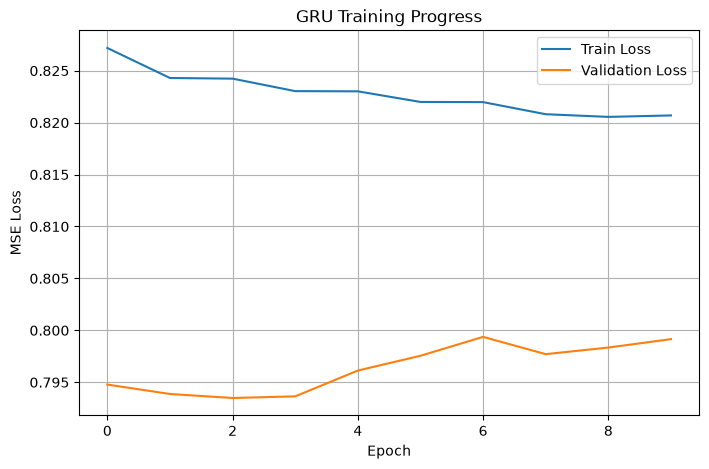

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training Progress")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Baseline 1: predict zero displacement for every window
zero_prediction = np.zeros_like(y_val)

zero_mse = mean_squared_error(
    y_val,
    zero_prediction
)

print("Zero-prediction validation MSE:", zero_mse)

Zero-prediction validation MSE: 0.7904629909170312


In [16]:
mean_prediction = np.tile(
    y_train.mean(axis=0),
    (len(y_val), 1)
)

mean_mse = mean_squared_error(
    y_val,
    mean_prediction
)

print("Mean-prediction validation MSE:", mean_mse)

Mean-prediction validation MSE: 0.79046371206443


In [17]:
model.eval()

predictions = []

with torch.no_grad():
    for X_batch, _ in val_loader:
        pred = model(X_batch)
        predictions.append(pred.numpy())

gru_predictions = np.concatenate(predictions)

gru_mse = mean_squared_error(
    y_val,
    gru_predictions
)

print("GRU validation MSE:", gru_mse)

GRU validation MSE: 0.7991517426454379


In [18]:
print("\nComparison")
print("----------------------------")
print("Zero baseline :", zero_mse)
print("Mean baseline :", mean_mse)
print("GRU           :", gru_mse)


Comparison
----------------------------
Zero baseline : 0.7904629909170312
Mean baseline : 0.79046371206443
GRU           : 0.7991517426454379


In [19]:
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)

print("Target mean:")
print(y_mean)

print("\nTarget std:")
print(y_std)

Target mean:
[ 0.00087794 -0.0002057  -0.00013153]

Target std:
[0.90364819 1.2859574  0.02647339]


In [20]:
y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std

In [21]:
y_train_tensor_norm = torch.tensor(
    y_train_norm,
    dtype=torch.float32
)

y_val_tensor_norm = torch.tensor(
    y_val_norm,
    dtype=torch.float32
)

train_dataset_norm = TensorDataset(
    X_train_tensor,
    y_train_tensor_norm
)

val_dataset_norm = TensorDataset(
    X_val_tensor,
    y_val_tensor_norm
)

train_loader_norm = DataLoader(
    train_dataset_norm,
    batch_size=64,
    shuffle=True
)

val_loader_norm = DataLoader(
    val_dataset_norm,
    batch_size=64,
    shuffle=False
)

print("Train:", len(train_dataset_norm))
print("Validation:", len(val_dataset_norm))

Train: 3030
Validation: 533


In [22]:
model_norm = GRUDeadReckoning()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_norm.parameters(),
    lr=0.001
)

In [23]:
num_epochs = 20

train_losses_norm = []
val_losses_norm = []

for epoch in range(num_epochs):

    model_norm.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader_norm:

        optimizer.zero_grad()

        predictions = model_norm(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader_norm.dataset)

    model_norm.eval()
    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader_norm:

            predictions = model_norm(X_batch)

            loss = criterion(predictions, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader_norm.dataset)

    train_losses_norm.append(train_loss)
    val_losses_norm.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} "
        f"| Train Loss: {train_loss:.6f} "
        f"| Val Loss: {val_loss:.6f}"
    )

Epoch 01/20 | Train Loss: 0.990314 | Val Loss: 1.005838
Epoch 02/20 | Train Loss: 0.979311 | Val Loss: 0.999799
Epoch 03/20 | Train Loss: 0.971282 | Val Loss: 0.985423
Epoch 04/20 | Train Loss: 0.960797 | Val Loss: 0.978601
Epoch 05/20 | Train Loss: 0.959422 | Val Loss: 0.970716
Epoch 06/20 | Train Loss: 0.957740 | Val Loss: 0.989645
Epoch 07/20 | Train Loss: 0.946217 | Val Loss: 0.960282
Epoch 08/20 | Train Loss: 0.940283 | Val Loss: 0.971569
Epoch 09/20 | Train Loss: 0.935520 | Val Loss: 0.958995
Epoch 10/20 | Train Loss: 0.932677 | Val Loss: 0.950493
Epoch 11/20 | Train Loss: 0.930108 | Val Loss: 0.952226
Epoch 12/20 | Train Loss: 0.925670 | Val Loss: 0.945344
Epoch 13/20 | Train Loss: 0.915725 | Val Loss: 0.940720
Epoch 14/20 | Train Loss: 0.915615 | Val Loss: 0.941102
Epoch 15/20 | Train Loss: 0.904525 | Val Loss: 0.931754
Epoch 16/20 | Train Loss: 0.893060 | Val Loss: 0.927857
Epoch 17/20 | Train Loss: 0.891745 | Val Loss: 0.901815
Epoch 18/20 | Train Loss: 0.885076 | Val Loss: 0

In [24]:
model_norm.eval()

predictions_norm = []

with torch.no_grad():

    for X_batch, _ in val_loader_norm:

        pred = model_norm(X_batch)

        predictions_norm.append(pred.numpy())

predictions_norm = np.concatenate(predictions_norm)

predictions_original = (
    predictions_norm * y_std
) + y_mean

In [25]:
from sklearn.metrics import mean_squared_error

normalized_gru_mse = mean_squared_error(
    y_val_norm,
    predictions_norm
)

original_gru_mse = mean_squared_error(
    y_val,
    predictions_original
)

print("Normalized validation MSE:", normalized_gru_mse)
print("Original-unit validation MSE:", original_gru_mse)

print("\nZero baseline:", zero_mse)
print("Mean baseline:", mean_mse)
print("New GRU:", original_gru_mse)

Normalized validation MSE: 0.9211350330489984
Original-unit validation MSE: 0.7964136525444317

Zero baseline: 0.7904629909170312
Mean baseline: 0.79046371206443
New GRU: 0.7964136525444317


In [26]:
model_norm.eval()

predictions_norm = []

with torch.no_grad():
    for X_batch, _ in val_loader_norm:
        pred = model_norm(X_batch)
        predictions_norm.append(pred.numpy())

predictions_norm = np.concatenate(predictions_norm)

# Convert predictions back to original displacement units
predictions_original = (
    predictions_norm * y_std
) + y_mean

print("Overall MSE:")
print(mean_squared_error(y_val, predictions_original))

print("\nPer-axis MSE:")

mse_x = mean_squared_error(y_val[:, 0], predictions_original[:, 0])
mse_y = mean_squared_error(y_val[:, 1], predictions_original[:, 1])
mse_z = mean_squared_error(y_val[:, 2], predictions_original[:, 2])

print("ΔX:", mse_x)
print("ΔY:", mse_y)
print("ΔZ:", mse_z)

print("\nBaselines:")
print("Zero:", zero_mse)
print("Mean:", mean_mse)

Overall MSE:
0.7964136525444317

Per-axis MSE:
ΔX: 0.7257843944598165
ΔY: 1.6628474939167501
ΔZ: 0.0006090692567286456

Baselines:
Zero: 0.7904629909170312
Mean: 0.79046371206443


In [27]:
rmse_x = np.sqrt(mse_x)
rmse_y = np.sqrt(mse_y)
rmse_z = np.sqrt(mse_z)

overall_rmse = np.sqrt(
    mean_squared_error(y_val, predictions_original)
)

print("Overall RMSE:", overall_rmse)
print("ΔX RMSE:", rmse_x)
print("ΔY RMSE:", rmse_y)
print("ΔZ RMSE:", rmse_z)

Overall RMSE: 0.8924201098946795
ΔX RMSE: 0.8519298060637487
ΔY RMSE: 1.2895144411431576
ΔZ RMSE: 0.02467932853074908


In [28]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Oxford Inertial Odometry Dataset_2.0"
    / "Oxford Inertial Odometry Dataset"
)

sequence_path = DATASET_ROOT / "handheld" / "data1" / "syn"

vi = pd.read_csv(
    sequence_path / "vi1.csv",
    header=None,
    names=[
        "time",
        "frame",
        "pos_x",
        "pos_y",
        "pos_z",
        "quat_x",
        "quat_y",
        "quat_z",
        "quat_w",
    ],
)

print(vi.shape)

(37602, 9)


In [29]:
print(vi[[
    "pos_x",
    "pos_y",
    "pos_z",
    "quat_x",
    "quat_y",
    "quat_z",
    "quat_w"
]].head(10))

    pos_x   pos_y   pos_z   quat_x    quat_y    quat_z   quat_w
0 -1.2991  1.7212  1.1931 -0.21409 -0.012459 -0.097183  0.97189
1 -1.2993  1.7213  1.1932 -0.21473 -0.012370 -0.097239  0.97174
2 -1.2993  1.7213  1.1932 -0.21509 -0.012288 -0.097244  0.97166
3 -1.2994  1.7214  1.1933 -0.21526 -0.012291 -0.097380  0.97161
4 -1.2995  1.7213  1.1933 -0.21541 -0.012199 -0.097503  0.97157
5 -1.2997  1.7214  1.1934 -0.21574 -0.012065 -0.097774  0.97147
6 -1.2998  1.7214  1.1934 -0.21528 -0.011872 -0.097794  0.97157
7 -1.2999  1.7213  1.1933 -0.21524 -0.011852 -0.098083  0.97155
8 -1.2999  1.7213  1.1931 -0.21421 -0.011941 -0.097952  0.97179
9 -1.3000  1.7213  1.1931 -0.21413 -0.011671 -0.098103  0.97180


In [30]:
quat_norm = np.sqrt(
    vi["quat_x"]**2 +
    vi["quat_y"]**2 +
    vi["quat_z"]**2 +
    vi["quat_w"]**2
)

print(quat_norm.describe())

count    37602.000000
mean         1.000000
std          0.000003
min          0.999992
25%          0.999998
50%          1.000000
75%          1.000002
max          1.000008
dtype: float64


In [31]:
print("Position ranges:")
print("X:", vi["pos_x"].min(), "to", vi["pos_x"].max())
print("Y:", vi["pos_y"].min(), "to", vi["pos_y"].max())
print("Z:", vi["pos_z"].min(), "to", vi["pos_z"].max())

Position ranges:
X: -1.7467 to 1.8069
Y: -2.8955 to 2.9487
Z: 1.1152 to 1.2653


In [32]:
print(vi[
    [
        "quat_x",
        "quat_y",
        "quat_z",
        "quat_w"
    ]
].head(10))

    quat_x    quat_y    quat_z   quat_w
0 -0.21409 -0.012459 -0.097183  0.97189
1 -0.21473 -0.012370 -0.097239  0.97174
2 -0.21509 -0.012288 -0.097244  0.97166
3 -0.21526 -0.012291 -0.097380  0.97161
4 -0.21541 -0.012199 -0.097503  0.97157
5 -0.21574 -0.012065 -0.097774  0.97147
6 -0.21528 -0.011872 -0.097794  0.97157
7 -0.21524 -0.011852 -0.098083  0.97155
8 -0.21421 -0.011941 -0.097952  0.97179
9 -0.21413 -0.011671 -0.098103  0.97180


In [33]:
import numpy as np

q = vi.loc[0, ["quat_x", "quat_y", "quat_z", "quat_w"]].to_numpy(dtype=float)

x, y, z, w = q

R = np.array([
    [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
    [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
    [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)]
])

print("Quaternion:")
print(q)

print("\nRotation matrix:")
print(R)

print("\nR @ R.T:")
print(R @ R.T)

print("\nDeterminant:")
print(np.linalg.det(R))

Quaternion:
[-0.21409  -0.012459 -0.097183  0.97189 ]

Rotation matrix:
[[ 0.98080048  0.19423707  0.01739426]
 [-0.18356768  0.88944187  0.41856547]
 [ 0.06582937 -0.41372225  0.90802049]]

R @ R.T:
[[ 1.00000017e+00 -4.76107625e-08 -3.71374647e-07]
 [-4.76107625e-08  1.00000099e+00 -2.16122039e-08]
 [-3.71374647e-07 -2.16122039e-08  1.00000082e+00]]

Determinant:
1.0000009894732553


In [34]:
import numpy as np

# Global displacement from first to last sample
p0 = vi[["pos_x", "pos_y", "pos_z"]].iloc[0].to_numpy(dtype=float)
p1 = vi[["pos_x", "pos_y", "pos_z"]].iloc[199].to_numpy(dtype=float)

delta_global = p1 - p0

# Initial quaternion
q = vi.loc[0, ["quat_x", "quat_y", "quat_z", "quat_w"]].to_numpy(dtype=float)

x, y, z, w = q

# Quaternion -> rotation matrix
R = np.array([
    [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
    [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
    [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)]
])

# Global -> initial local/body frame
delta_local = R.T @ delta_global

print("Global displacement:")
print(delta_global)

print("\nLocal displacement:")
print(delta_local)

Global displacement:
[ 0.0004 -0.0014  0.0025]

Local displacement:
[ 0.00081389 -0.00220183  0.00169102]


In [35]:
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Oxford Inertial Odometry Dataset_2.0"
    / "Oxford Inertial Odometry Dataset"
)

# Test on the same sequence we inspected
sequence_path = DATASET_ROOT / "handheld" / "data1" / "syn"

imu = pd.read_csv(
    sequence_path / "imu1.csv",
    header=None,
    names=[
        "time",
        "attitude_roll",
        "attitude_pitch",
        "attitude_yaw",
        "gyro_x",
        "gyro_y",
        "gyro_z",
        "gravity_x",
        "gravity_y",
        "gravity_z",
        "acc_x",
        "acc_y",
        "acc_z",
        "mag_x",
        "mag_y",
        "mag_z",
    ],
)

vi = pd.read_csv(
    sequence_path / "vi1.csv",
    header=None,
    names=[
        "time",
        "frame",
        "pos_x",
        "pos_y",
        "pos_z",
        "quat_x",
        "quat_y",
        "quat_z",
        "quat_w",
    ],
)

WINDOW_SIZE = 200
STRIDE = 200


def quaternion_to_rotation_matrix(q):
    x, y, z, w = q

    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)]
    ])


local_targets = []

for start in range(0, len(vi) - WINDOW_SIZE + 1, STRIDE):

    end = start + WINDOW_SIZE - 1

    # Global displacement
    p_start = vi.loc[
        start, ["pos_x", "pos_y", "pos_z"]
    ].to_numpy(dtype=float)

    p_end = vi.loc[
        end, ["pos_x", "pos_y", "pos_z"]
    ].to_numpy(dtype=float)

    delta_global = p_end - p_start

    # Initial orientation
    q = vi.loc[
        start, ["quat_x", "quat_y", "quat_z", "quat_w"]
    ].to_numpy(dtype=float)

    R = quaternion_to_rotation_matrix(q)

    # Convert global displacement -> initial local/body frame
    delta_local = R.T @ delta_global

    local_targets.append(delta_local)

local_targets = np.asarray(local_targets)

print("Local target shape:", local_targets.shape)

print("\nFirst 10 local targets:")
print(local_targets[:10])

print("\nStatistics:")
print("Mean:", local_targets.mean(axis=0))
print("Std :", local_targets.std(axis=0))
print("Min :", local_targets.min(axis=0))
print("Max :", local_targets.max(axis=0))

Local target shape: (188, 3)

First 10 local targets:
[[ 8.13888368e-04 -2.20182943e-03  1.69101728e-03]
 [ 2.26367964e-01 -7.78698776e-01 -3.88557255e-01]
 [ 3.58551350e-01 -1.33617330e+00 -6.98152135e-01]
 [ 6.14866614e-01 -1.15023120e+00 -7.10051196e-01]
 [ 1.39346220e+00 -3.23171884e-01 -3.38833405e-03]
 [ 1.22599214e+00 -8.25420817e-01 -3.26320422e-01]
 [ 9.92315024e-01 -1.07629736e+00 -5.42269910e-01]
 [ 5.00404768e-01 -1.35695519e+00 -6.19765430e-01]
 [ 8.40057870e-01 -9.83184675e-01 -5.40424404e-01]
 [ 1.39733959e+00 -3.96756722e-01 -1.36869393e-01]]

Statistics:
Mean: [ 1.03733078 -0.907516   -0.43111223]
Std : [0.36699178 0.34734262 0.17404165]
Min : [-0.03423679 -1.53118664 -0.72867775]
Max : [ 1.60385232 -0.00220183  0.00169102]
